In [29]:
!python --version

Python 3.12.13


In [30]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"mdalimranroton","key":"77970a92a73d89c8164499b9d653fd8b"}'}

In [31]:
import os

os.makedirs('/root/.kaggle', exist_ok=True)
!mv kaggle.json /root/.kaggle/

In [32]:
!chmod 600 /root/.kaggle/kaggle.json

In [33]:
!kaggle datasets list

ref                                                                 title                                                     size  lastUpdated                 downloadCount  voteCount  usabilityRating  
------------------------------------------------------------------  --------------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
nalisha/job-salary-prediction-dataset                               Job Salary Prediction Dataset                          3144815  2026-03-16 19:54:33.843000          11641        277                1  
algozee/teenager-menthal-healy                                      Social Media Impact on Teen Mental Health                16190  2026-04-05 08:04:21.823000           2884         65                1  
sumeakash/impact-of-social-media-on-health                          Impact of Social Media on Health                         18598  2026-04-05 06:53:55.953000           2935         71

In [34]:
!kaggle datasets download -d nalisha/job-salary-prediction-dataset

Dataset URL: https://www.kaggle.com/datasets/nalisha/job-salary-prediction-dataset
License(s): CC0-1.0
100% 3.00M/3.00M [00:00<00:00, 182MB/s]



In [37]:
!kaggle datasets download -h dogs-vs-cats

usage: kaggle datasets download [-h] [-f FILE_NAME] [-p PATH] [-w] [--unzip]
                                [-o] [-q]
                                [dataset]

options:
  -h, --help            show this help message and exit
  dataset               Dataset URL suffix in format <owner>/<dataset-name> (use "kaggle datasets list" to show options)
  -f FILE_NAME, --file FILE_NAME
                        File name, all files downloaded if not provided
                        (use "kaggle datasets files -d <dataset>" to show options)
  -p PATH, --path PATH  Folder where file(s) will be downloaded, defaults to current working directory
  -w, --wp              Download files to current working path
  --unzip               Unzip the downloaded file. Will delete the zip file when completed.
  -o, --force           Skip check whether local version of file is up to date, force file download
  -q, --quiet           Suppress printing information about the upload/download progress


In [38]:
!kaggle datasets list -s dogs-vs-cats

ref                                                    title                                                size  lastUpdated                 downloadCount  voteCount  usabilityRating  
-----------------------------------------------------  ---------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
shaunthesheep/microsoft-catsvsdogs-dataset             Cats-vs-Dogs                                    825979578  2020-03-12 05:34:30.730000         102084        935  0.875            
biaiscience/dogs-vs-cats                               Dogs vs Cats                                    856265363  2017-12-05 14:03:33.210000          30242        362  0.4375           
pybear/cats-vs-dogs                                    Cats -- VS -- Dogs                              825979578  2020-10-18 13:55:30.950000           3151        103  0.625            
sujaykapadnis/cats-vs-dogs                             Cats Vs Dogs   

In [39]:
!kaggle competitions download -c dogs-vs-cats

401 Client Error: Unauthorized for url: https://api.kaggle.com/v1/competitions.CompetitionApiService/DownloadDataFiles


In [1]:
!kaggle datasets download -d shaunthesheep/microsoft-catsvsdogs-dataset --unzip

Dataset URL: https://www.kaggle.com/datasets/shaunthesheep/microsoft-catsvsdogs-dataset
License(s): other
100% 788M/788M [00:05<00:00, 160MB/s]



In [2]:
import tensorflow as tf
from tensorflow.keras import layers, models
import os

In [3]:
DATA_DIR = "/content/PetImages"   # change if needed
IMG_SIZE = (128, 128)
BATCH_SIZE = 32

In [20]:
from PIL import Image
import os

In [21]:
# Identify and remove corrupt images
num_skipped = 0
for folder_name in ("Cat", "Dog"):
    folder_path = os.path.join(DATA_DIR, folder_name)
    for fname in os.listdir(folder_path):
        fpath = os.path.join(folder_path, fname)
        try:
            fobj = open(fpath, "rb")
            is_jfif = tf.compat.as_bytes("JFIF") in fobj.peek(10)
        finally:
            fobj.close()

        if not is_jfif:
            num_skipped += 1
            # Delete corrupted image
            os.remove(fpath)

print(f"Deleted {num_skipped} images due to invalid JFIF header")

Deleted 0 images due to invalid JFIF header


In [22]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

Found 23410 files belonging to 2 classes.
Using 18728 files for training.
Found 23410 files belonging to 2 classes.
Using 4682 files for validation.


In [23]:
class_names = train_ds.class_names
print(class_names)

['Cat', 'Dog']


In [24]:
train_ds

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>

Streaming output truncated to the last 5000 lines.
tf.Tensor(
[[[227.      226.      231.     ]
  [229.39062 228.39062 233.39062]
  [232.42188 231.42188 236.42188]
  ...
  [215.5625  213.5625  214.5625 ]
  [215.5625  213.5625  214.5625 ]
  [215.5625  213.5625  214.5625 ]]

 [[227.51562 226.51562 231.51562]
  [228.9375  227.9375  232.9375 ]
  [230.60938 229.60938 234.60938]
  ...
  [213.6875  211.6875  212.6875 ]
  [213.6875  211.6875  212.6875 ]
  [213.6875  211.6875  212.6875 ]]

 [[225.625   224.625   229.625  ]
  [225.82812 224.82812 229.82812]
  [226.4375  225.4375  230.4375 ]
  ...
  [211.625   209.625   210.625  ]
  [211.625   209.625   210.625  ]
  [211.625   209.625   210.625  ]]

 ...

 [[200.67188 197.29688 192.48438]
  [181.0625  173.96875 167.51562]
  [177.17188 166.95312 158.09375]
  ...
  [253.8125  253.8125  253.8125 ]
  [253.8125  253.8125  253.8125 ]
  [253.8125  253.8125  253.8125 ]]

 [[205.04688 204.39062 199.21875]
  [197.26562 193.3125  186.125  ]
  [188.4375  180

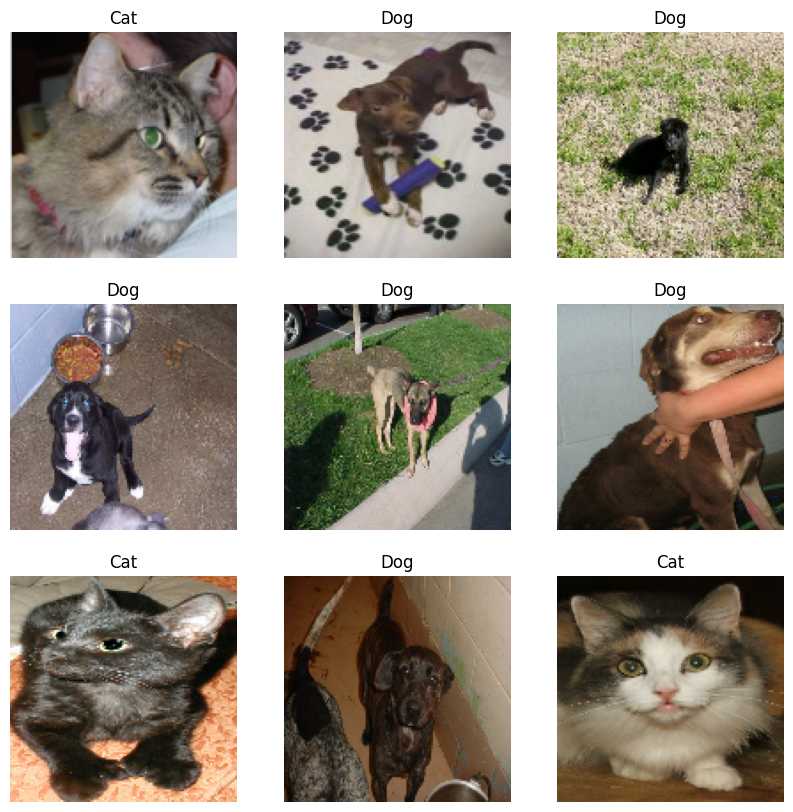

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))

for images, labels in train_ds.take(12):
    for i in range(9):  # show 9 images
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        print(images[i])
        plt.title(class_names[labels[i]])
        plt.axis("off")

plt.show()

In [14]:
from tensorflow import keras
from tensorflow.keras import layers
inputs = keras.Input(shape = (128,128,3))
x= layers.Rescaling(1./255)(inputs)
x= layers.Conv2D(filters=32, kernel_size=3, activation="relu")(x)
x= layers.MaxPooling2D(pool_size=2)(x)
x= layers.Conv2D(filters=64, kernel_size=3, activation="relu")(x)
x= layers.MaxPooling2D(pool_size=2)(x)
x= layers.Conv2D(filters=128, kernel_size=3, activation="relu")(x)
x= layers.MaxPooling2D(pool_size=2)(x)
x= layers.Conv2D(filters=256, kernel_size=3, activation="relu")(x)
x= layers.MaxPooling2D(pool_size=2)(x)
x= layers.Conv2D(filters=256, kernel_size=3, activation="relu")(x)
x= layers.Flatten()(x)
outputs= layers.Dense(1, activation="sigmoid")(x)
model= keras.Model(inputs=inputs, outputs=outputs)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 4, 4, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         4,097 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 982,593 (3.75 MB)

 Trainable params: 982,593 (3.75 MB)

 Non-trainable params: 0 (0.00 B)

In [15]:
model.compile(
    loss=keras.losses.BinaryCrossentropy(),
    optimizer=keras.optimizers.RMSprop(),
    metrics=["accuracy"],
)


In [16]:
callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath="convnet_from_scratch.keras",
        save_best_only=True,
        monitor="val_loss"
    )
]

In [26]:
history = model.fit(
    train_ds,
    epochs=5,
    validation_data=val_ds,
    callbacks=callbacks
)

Epoch 1/5
586/586 ━━━━━━━━━━━━━━━━━━━━ 39s 66ms/step - accuracy: 0.6985 - loss: 0.5777 - val_accuracy: 0.6856 - val_loss: 0.6738
Epoch 2/5
586/586 ━━━━━━━━━━━━━━━━━━━━ 32s 51ms/step - accuracy: 0.7868 - loss: 0.4511 - val_accuracy: 0.7484 - val_loss: 0.5376
Epoch 3/5
586/586 ━━━━━━━━━━━━━━━━━━━━ 30s 50ms/step - accuracy: 0.8431 - loss: 0.3612 - val_accuracy: 0.8552 - val_loss: 0.3273
Epoch 4/5
586/586 ━━━━━━━━━━━━━━━━━━━━ 46s 59ms/step - accuracy: 0.8746 - loss: 0.2897 - val_accuracy: 0.8496 - val_loss: 0.3622
Epoch 5/5
586/586 ━━━━━━━━━━━━━━━━━━━━ 35s 50ms/step - accuracy: 0.9027 - loss: 0.2323 - val_accuracy: 0.8725 - val_loss: 0.3143


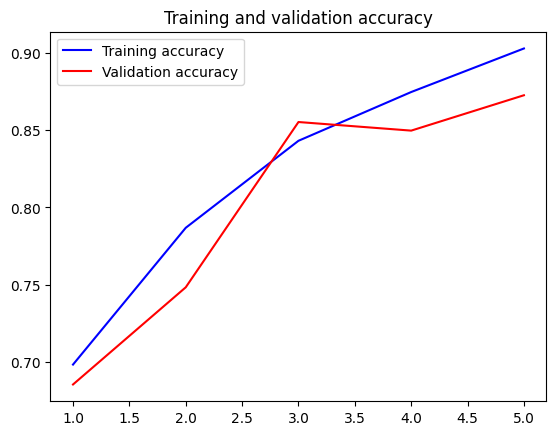

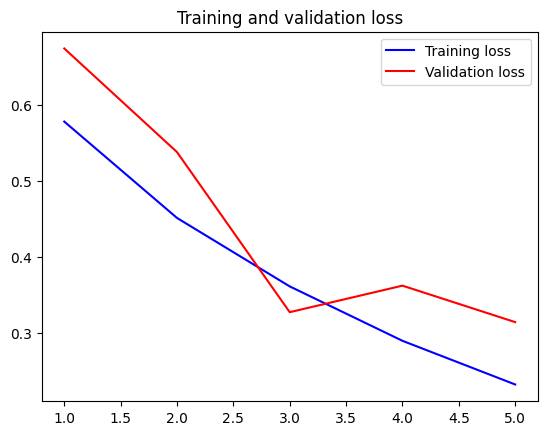

In [28]:
import matplotlib.pyplot as plt
accuracy = history.history["accuracy"]
val_accuracy = history.history["val_accuracy"]
loss = history.history["loss"]
val_loss = history.history["val_loss"]
epochs = range(1, len(accuracy)+1)
plt.plot(epochs, accuracy, "b", label="Training accuracy")
plt.plot(epochs, val_accuracy, "r", label="Validation accuracy")
plt.title("Training and validation accuracy")
plt.legend()
plt.figure()
plt.plot(epochs, loss, "b", label="Training loss")
plt.plot(epochs, val_loss, "r", label="Validation loss")
plt.title("Training and validation loss")
plt.legend()
plt.show()